<a href="https://colab.research.google.com/github/viktoriia-yarmolchuk/portfolio-projects/blob/main/analysis_of_ecommerce_sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import auth
from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy.stats import normaltest, spearmanr

## Connecting to a database in Goggle BigQuery

In [ ]:
auth.authenticate_user()

In [ ]:
client = bigquery.Client(project="data-analytics-mate")

In [ ]:
query = """
SELECT
    s.date,
    p.*,
    pr.name AS product_name,
    pr.category AS product_category,
    pr.price AS item_price,
    pr.short_description,
    acs.account_id,
    ac.is_verified,
    ac.is_unsubscribed
FROM `DA.session` s
LEFT JOIN `DA.session_params` p USING (ga_session_id)
LEFT JOIN `DA.order` o USING (ga_session_id)
LEFT JOIN `DA.product` pr USING (item_id)
LEFT JOIN `DA.account_session` acs USING (ga_session_id)
LEFT JOIN `DA.account` ac ON acs.account_id = ac.id;
"""

In [ ]:
query_job = client.query(query)
results = query_job.result()

df = results.to_dataframe()

## Dataset Overview

In [ ]:
df.head()

,date,ga_session_id,device,mobile_model_name,operating_system,language,browser,continent,country,medium,name,channel,product_name,product_category,item_price,short_description,account_id,is_verified,is_unsubscribed
0,2020-11-01,967742695,desktop,Safari,Web,en-us,Safari,Americas,United States,(data deleted),(data deleted),Undefined,VITTSJÖ,Bookcases & shelving units,609.0,"Shelving unit with laptop table, 202x36x175 cm",<NA>,<NA>,<NA>
1,2020-11-01,9065007548,desktop,Safari,Web,None,Chrome,Asia,China,(data deleted),(data deleted),Undefined,VITTSJÖ,Bookcases & shelving units,609.0,"Shelving unit with laptop table, 202x36x175 cm",<NA>,<NA>,<NA>
2,2020-11-01,3267062634,desktop,Safari,Web,en-us,Chrome,Americas,United States,(data deleted),(data deleted),Undefined,VITTSJÖ,Bookcases & shelving units,609.0,"Shelving unit with laptop table, 202x36x175 cm",<NA>,<NA>,<NA>
3,2020-11-01,8892952409,mobile,<Other>,Web,ko,Android Webview,Americas,United States,(data deleted),(data deleted),Undefined,None,None,NaN,None,<NA>,<NA>,<NA>
4,2020-11-01,1624570787,desktop,<Other>,Web,en-us,<Other>,Asia,Turkey,(data deleted),(data deleted),Undefined,None,None,NaN,None,<NA>,<NA>,<NA>


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 19 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   date               349545 non-null  dbdate 
 1   ga_session_id      349545 non-null  Int64  
 2   device             349545 non-null  object 
 3   mobile_model_name  349545 non-null  object 
 4   operating_system   349545 non-null  object 
 5   language           235279 non-null  object 
 6   browser            349545 non-null  object 
 7   continent          349545 non-null  object 
 8   country            349545 non-null  object 
 9   medium             349545 non-null  object 
 10  name               349545 non-null  object 
 11  channel            349545 non-null  object 
 12  product_name       33538 non-null   object 
 13  product_category   33538 non-null   object 
 14  item_price         33538 non-null   float64
 15  short_description  33538 non-null   object 
 16  ac

The dataset contains 349,545 total entries across 19 columns. It tracks user session activity, geographic data, and transaction details.

The number of numerical columns is 5 (columns containing IDs, item price, and subscriber information with values of 1 or 0).

Number of categorical columns: 13 (device, mobile_model_name, operating_system, language, browser, continent, country, medium, name, channel, product_name, product_category, short_description).

There is 1 column with the datetime type: date (session date).

In [ ]:
df['ga_session_id'].nunique()

349545

Number of unique sessions: 349545

In [ ]:
print(f'The time period is from {df['date'].min()} to {df['date'].max()}')

The time period is from 2020-11-01 to 2021-01-31


The data spans from November 1, 2020, to January 31, 2021.

Number of missing values:

In [ ]:
df.isnull().sum()

,0
date,0
ga_session_id,0
device,0
mobile_model_name,0
operating_system,0
language,114266
browser,0
continent,0
country,0
medium,0


The presence of missing values in the dataset is a direct result of the data integration process. The final dataset was constructed by joining session-level data with separate sales and account tables. Consequently, null values appear in rows where a specific session did not involve a transaction or the creation/use of a user account.

Percentage of missing values:

In [ ]:
df.isnull().mean() * 100

,0
date,0.000000
ga_session_id,0.000000
device,0.000000
mobile_model_name,0.000000
operating_system,0.000000
language,32.689925
browser,0.000000
continent,0.000000
country,0.000000
medium,0.000000


Columns related to product interactions and orders (product_name, product_category, item_price, short_description, and order_date) each contain 316,007 missing values. This accounts for approximately 90.4% of the total dataset.

These fields are only populated when a session is successfully linked to a purchase record. The high number of nulls indicates that most sessions did not result in a transaction.

The columns account_id, is_verified, and is_unsubscribed have the highest number of null entries, totaling 321,600 each. This represents 92.0% of the total records.

These values are missing for sessions where users were browsing as guests or did not perform any account-related actions (such as registration or logging in) during that visit.

The language column exhibits 114,266 missing values. Approximately 32.7% of the total entries. Unlike the joined tables, this missingness is likely due to technical factors in the initial data collection, such as browser privacy settings or the inability of the tracking script to identify the user's locale.

Fill in the blanks in the language column with the value "unknown":

In [ ]:
df['language'] = df['language'].fillna('unknown')

Missing values in account-related and order-related columns will be retained without imputation. These nulls are a natural outcome of joining session-level data with external sales and account tables.

The absence of data in these fields indicates that no transaction or account interaction occurred during those specific sessions.

## Key performance metrics

In [ ]:
total_revenue = df['item_price'].sum()
print(f'Total Revenue: {total_revenue/1e6:.2f} millions')

aov = df['item_price'].mean()
print(f'\nAverage Order Value: {aov:.1f}')

converion_rate = df['product_name'].count() / df['ga_session_id'].count() * 100
print(f'\nConversion Rate: {converion_rate:.2f} %')

logged_in_rate = df['account_id'].count() / df['ga_session_id'].count() * 100
print(f'\nLogged-in Rate: {logged_in_rate:.2f} %')

verification_rate = df['is_verified'].sum() / df['account_id'].count() * 100
print(f'\nVerification Rate: {verification_rate:.2f} %')

unsubscribe_rate = df['is_unsubscribed'].sum() / df['account_id'].count() * 100
print(f'\nUnsubscribe Rate: {unsubscribe_rate:.2f} %')

Total Revenue: 31.97 millions

Average Order Value: 953.3

Conversion Rate: 9.59 %

Logged-in Rate: 7.99 %

Verification Rate: 71.70 %

Unsubscribe Rate: 16.94 %


### Sales by Continent

In [ ]:
continent_sales = df.groupby('continent')['item_price'].sum().sort_values(ascending=False).reset_index().head(3)
continent_sales

,continent,item_price
0,Americas,17665280.0
1,Asia,7601298.3
2,Europe,5934624.2


In [ ]:
continent_sales_count = df.groupby('continent')['item_price'].count().sort_values(ascending=False).reset_index().head(3)
continent_sales_count

,continent,item_price
0,Americas,18553
1,Asia,7950
2,Europe,6261


In [ ]:
plt.style.use('seaborn-v0_8-pastel')

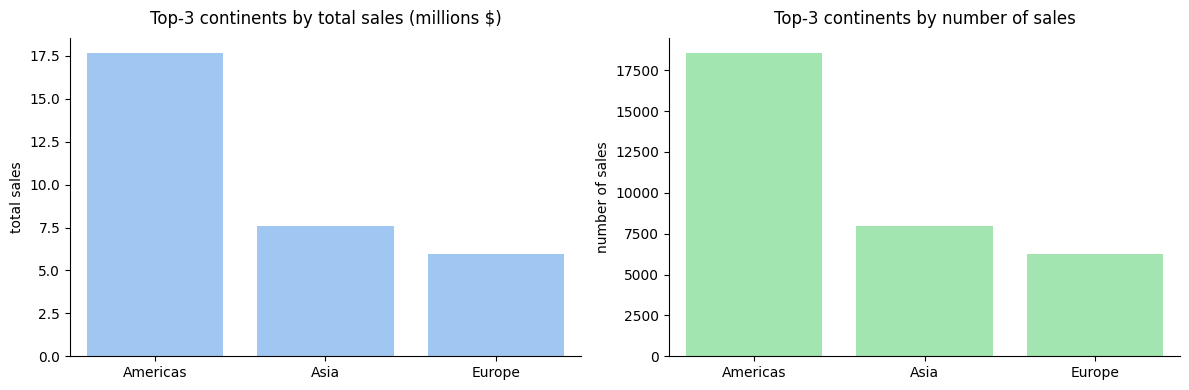

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1, 2, 1)
sns.barplot(data=continent_sales, x='continent', y=continent_sales['item_price']/1e6, errorbar=None)
plt.title('Top-3 continents by total sales (millions $)', pad=10)
plt.ylabel('total sales')
plt.xlabel(None)
sns.despine(ax=None)

plt.subplot(1, 2, 2)
sns.barplot(data=continent_sales_count, x='continent', y='item_price', errorbar=None, color='#97f0aa')
plt.title('Top-3 continents by number of sales', pad=10)
plt.ylabel('number of sales')
plt.xlabel(None)
sns.despine(ax=None)

plt.tight_layout()
plt.show()

The Americas region is the main revenue driver, generating over $17.5 million in revenue from 18,500 orders. This region’s performance is more than double that of Asia and Europe, making it a key market for the company.

### Sales by Country

In [ ]:
country_sales = df.groupby('country')['item_price'].sum().sort_values(ascending=False).reset_index().head(5)
country_sales

,country,item_price
0,United States,13943553.9
1,India,2809762.0
2,Canada,2437921.0
3,United Kingdom,938317.9
4,France,710692.8


In [ ]:
country_sales_count = df.groupby('country')['item_price'].count().sort_values(ascending=False).reset_index().head(5)
country_sales_count

,country,item_price
0,United States,14673
1,India,3029
2,Canada,2560
3,United Kingdom,1029
4,France,678


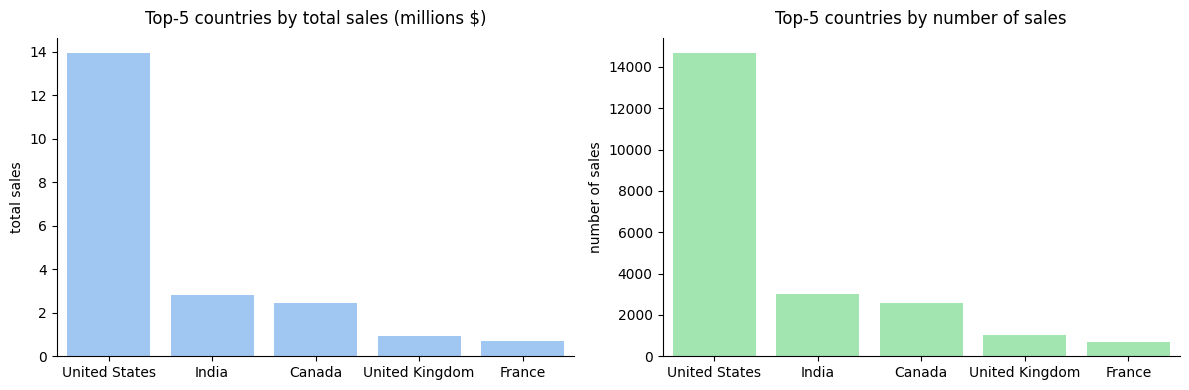

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1, 2, 1)
sns.barplot(data=country_sales, x='country', y=country_sales['item_price']/1e6, errorbar=None)
plt.title('Top-5 countries by total sales (millions $)', pad=10)
plt.ylabel('total sales')
plt.xlabel(None)
sns.despine(ax=None)

plt.subplot(1, 2, 2)
sns.barplot(data=country_sales_count, x='country', y='item_price', errorbar=None, color='#97f0aa')
plt.title('Top-5 countries by number of sales', pad=10)
plt.ylabel('number of sales')
plt.xlabel(None)
sns.despine(ax=None)

plt.tight_layout()
plt.show()

The United States is the leader, showing a huge gap from other countries with figures of about $14 million in revenue and over 14 thousand orders. India and Canada confidently occupy the second and third positions, and their contribution to total sales is quite stable and proportional.

In [ ]:
product_sales = df.groupby('product_category')['item_price'].sum().sort_values(ascending=False).reset_index().head(10)
product_sales

,product_category,item_price
0,Sofas & armchairs,8388254.5
1,Chairs,6147748.8
2,Beds,4919725.0
3,Bookcases & shelving units,3640818.1
4,Cabinets & cupboards,2336499.5
5,Outdoor furniture,2142222.2
6,Tables & desks,1790307.5
7,Chests of drawers & drawer units,906562.5
8,Bar furniture,735503.0
9,Children's furniture,467697.0


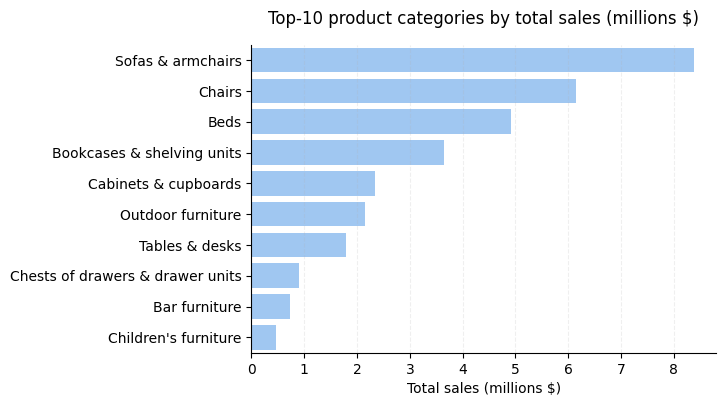

In [ ]:
plt.figure(figsize=(6, 4))

sns.barplot(data=product_sales, x=product_sales['item_price']/1e6, y='product_category', errorbar=None)
plt.title('Top-10 product categories by total sales (millions $)', pad=15)
plt.xlabel('Total sales (millions $)')
plt.ylabel(None)
sns.despine(ax=None)
plt.grid(axis='x', linestyle='--', alpha=0.2)

plt.show()

The Sofas & armchairs category is the absolute leader, generating over $8 million in revenue. Together with Chairs and Beds, these three product groups form the bulk of the company's revenue.

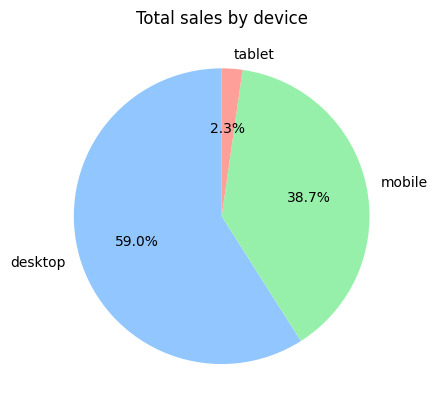

In [ ]:
device_sales = df.groupby('device')['item_price'].sum()
plt.pie(
    device_sales,
    labels=device_sales.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Total sales by device')
plt.show()

The majority of sales are on desktop devices (59.0%), making them the primary revenue channel. Mobile users also form a significant market share (38.7%), while tablet usage for shopping is minimal.

In [ ]:
os_sales = df.groupby('operating_system')['item_price'].sum().sort_values(ascending=False).reset_index()
os_sales

,operating_system,item_price
0,Web,18445904.5
1,Windows,3804989.0
2,iOS,3603329.4
3,Android,2789985.1
4,Macintosh,2504967.3
5,<Other>,822555.8


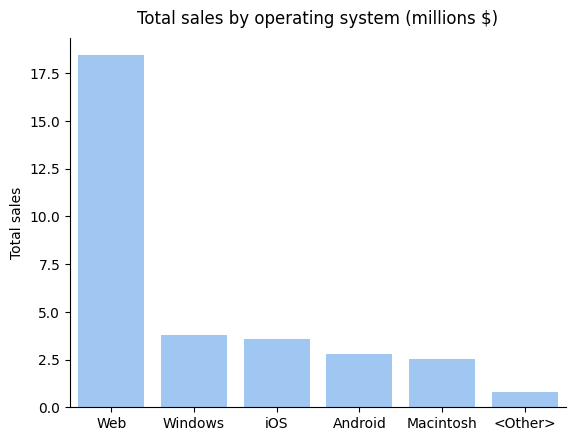

In [ ]:
sns.barplot(data=os_sales, x='operating_system', y=os_sales['item_price']/1e6, errorbar=None)
plt.title('Total sales by operating system (millions $)', pad=10)
plt.ylabel('Total sales')
plt.xlabel(None)
sns.despine(ax=None)

plt.show()

The Web platform is the absolute leader in terms of sales, generating over $18 million in revenue. The figures for other operating systems, such as Windows, iOS, and Android, are much lower and range between 2.5 million and 4 million.

In [ ]:
web = df[(df['operating_system'] == 'Web')]

web_sales = web.groupby('browser')['item_price'].sum().sort_values(ascending=False).reset_index()
web_sales

,browser,item_price
0,Chrome,13132192.7
1,Safari,3646097.0
2,<Other>,538694.2
3,Edge,468623.4
4,Firefox,344999.8
5,Android Webview,315297.4


An analysis of total sales by web browser shows the total dominance of Chrome, which generated over 13.1 million in revenue. Safari is in a strong second place with around 3.6 million, while the financial contribution of all other platforms (including Edge, Firefox, and Android Webview) turned out to be minimal, as none of them even surpassed the 550,000 threshold.

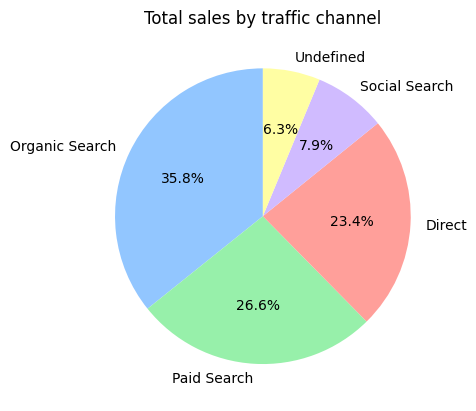

In [ ]:
channel_sales = df.groupby('channel')['item_price'].sum().sort_values(ascending=False)
plt.pie(
    channel_sales,
    labels=channel_sales.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Total sales by traffic channel')
plt.show()

The main revenue driver is organic search, which accounts for 35.8%. Paid search and direct conversions also play a significant role, providing 26.6% and 23.4% of sales respectively, while the contribution of social networks and other undefined sources is minimal and does not exceed 15% in total.

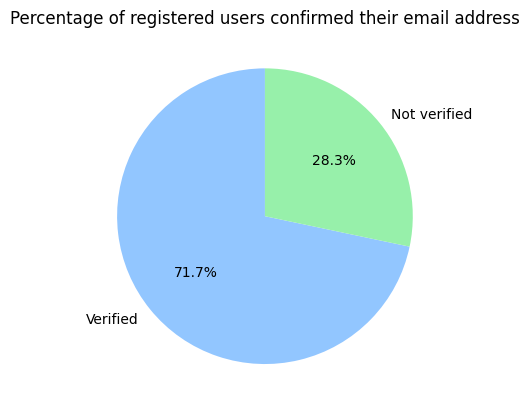

In [ ]:
verified = df['is_verified'].value_counts().rename(index={1: 'Verified', 0: 'Not verified'})

plt.pie(
    verified,
    labels=verified.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Percentage of registered users confirmed their email address')
plt.show()

The vast majority of registered users (71.7%) successfully confirmed their email address and received verified status. At the same time, a significant part of the audience — more than a quarter of the total (28.3%) — still remains unverified, which may indicate the need to optimize the onboarding or user activation process.

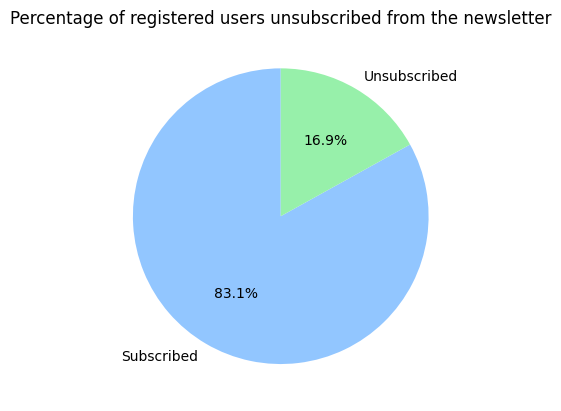

In [ ]:
subscribed = df['is_unsubscribed'].value_counts().rename(index={1: 'Unsubscribed', 0: 'Subscribed'})

plt.pie(
    subscribed,
    labels=subscribed.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Percentage of registered users unsubscribed from the newsletter')
plt.show()

The vast majority of registered users (83.1%) remain subscribed to the newsletter (Subscribed). The share of those who canceled the subscription (Unsubscribed) is relatively low and amounts to only 16.9%.

## Sales dynamics analysis

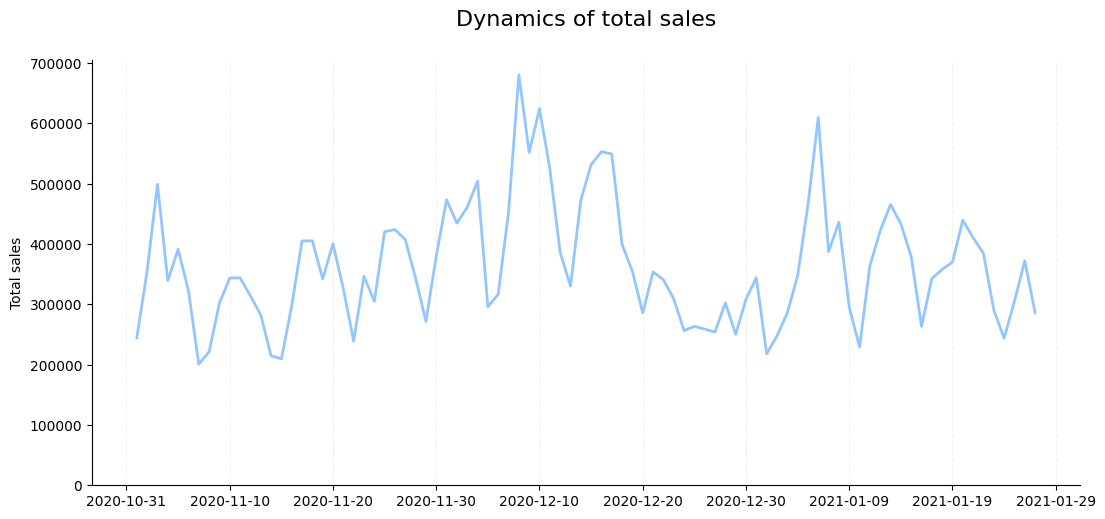

In [ ]:
sns.relplot(
    data=df,
    x='date',
    y='item_price',
    estimator=np.sum,
    errorbar=None,
    kind='line',
    aspect=2.2,
    linewidth=2)
plt.title('Dynamics of total sales', pad=25, fontsize=16)
plt.ylabel('Total sales')
plt.ylim(0)
plt.xlabel(None)
plt.grid(axis='x', linestyle='--', alpha=0.2)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.DayLocator(interval=10))

plt.show()

The dynamics of total sales for the period from November 2020 to the end of January 2021 are characterized by significant volatility and pronounced seasonality. Recent sales for the entire period under review are mainly in the range of 200,000 to 500,000 units, however, the largest surge in activity with an absolute peak (almost 700,000) occurs in the first half of December 2020, which is likely related to the pre-New Year shopping season. This is followed by a sharp decline in the second half of December and January, which occurs with occasional short-term increases, in particular in early January 2021.

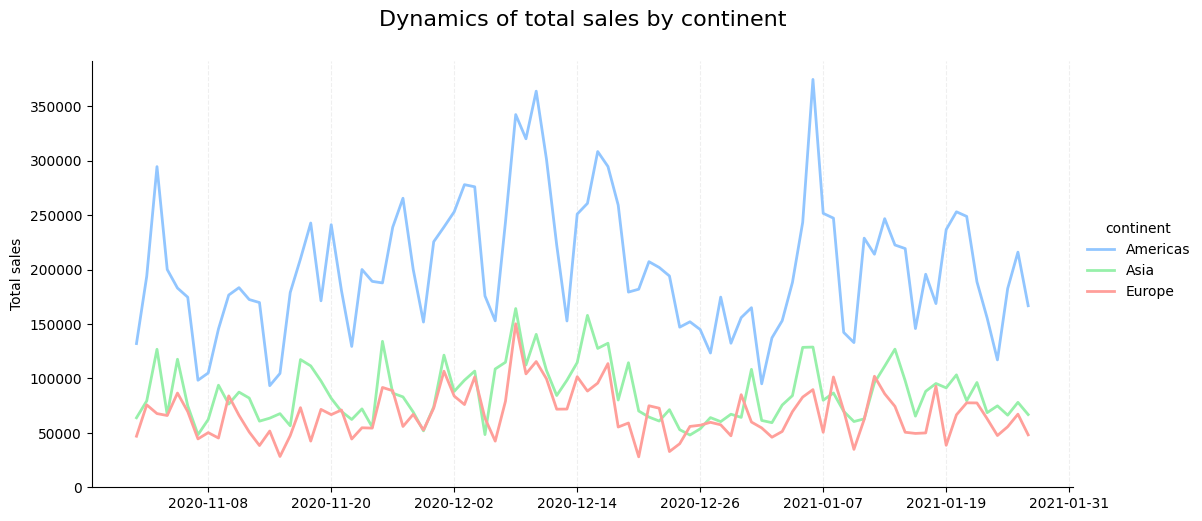

In [ ]:
cont_top3 = continent_sales['continent']

sns.relplot(
    data=df[df['continent'].isin(cont_top3)],
    x='date',
    y='item_price',
    estimator=np.sum,
    errorbar=None,
    kind='line',
    aspect=2.2,
    hue='continent',
    linewidth=2)
plt.title('Dynamics of total sales by continent', pad=25, fontsize=16)
plt.ylabel('Total sales')
plt.ylim(0)
plt.xlabel(None)
plt.grid(axis='x', linestyle='--', alpha=0.2)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.DayLocator(interval=12))

plt.show()

The Americas region is the absolute leader with the highest volumes and the largest fluctuations in sales, peaking twice at over 350,000 units (in early December and January).

In contrast, the Asia and Europe markets show significantly lower and very similar sales volumes, which usually fluctuate between 30,000 and 150,000 units. At the same time, the graphs of Asia and Europe almost synchronously repeat each other's general trends, demonstrating a joint rise in the first half of December and a moderate decline at the end of the year.

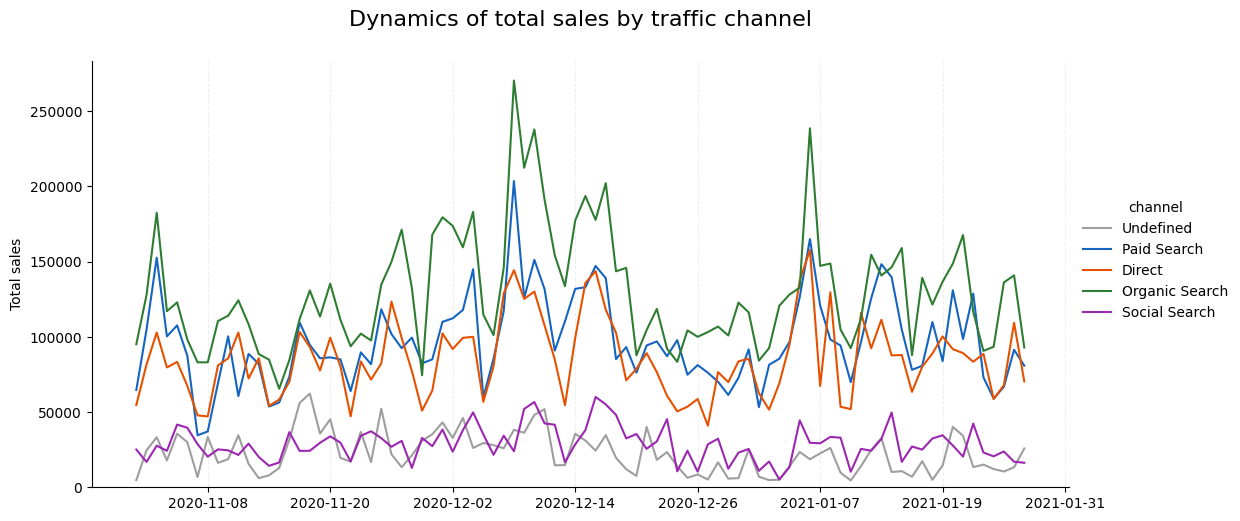

In [ ]:
channel_palette = {
    "Organic Search": "#2E7D32",
    "Paid Search": "#1565C0",
    "Direct": "#E65100",
    "Social Search": "#9C27B0",
    "Undefined": "#9E9E9E"
}

sns.relplot(
    data=df,
    x='date',
    y='item_price',
    estimator=np.sum,
    errorbar=None,
    kind='line',
    aspect=2.2,
    hue='channel',
    palette=channel_palette,
    linewidth=1.5)
plt.title('Dynamics of total sales by traffic channel', pad=25, fontsize=16)
plt.ylabel('Total sales')
plt.ylim(0)
plt.xlabel(None)
plt.grid(axis='x', linestyle='--', alpha=0.2)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.DayLocator(interval=12))

plt.show()

The main driver of sales throughout the period is the Organic Search channel, which consistently maintains leadership and shows the highest peak (over 250,000 units) in the first half of December. The Paid Search and Direct channels develop very synchronously, competing closely with each other at the level of 50,000–150,000 units, while the outsiders with the lowest sales volumes remain the Social Search and Undefined audiences.

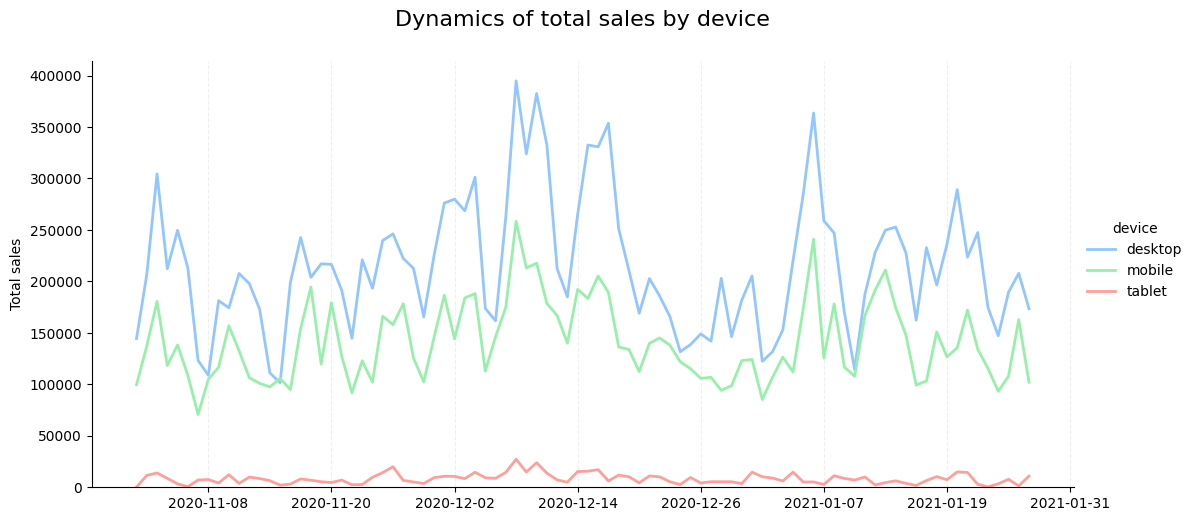

In [ ]:
sns.relplot(
    data=df,
    x='date',
    y='item_price',
    estimator=np.sum,
    errorbar=None,
    kind='line',
    aspect=2.2,
    hue='device',
    linewidth=2)
plt.title('Dynamics of total sales by device', pad=25, fontsize=16)
plt.ylabel('Total sales')
plt.ylim(0)
plt.xlabel(None)
plt.grid(axis='x', linestyle='--', alpha=0.2)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.DayLocator(interval=12))

plt.show()

The absolute leader in sales volumes is desktop, which consistently outperforms other devices throughout the period and shows the largest peak (almost 400,000 units) in the first half of December. The mobile graph completely duplicates the leader's fluctuations, but at a lower level — mostly within 100,000–200,000 units, while tablet sales remain minimal and consistently hover around zero.

In [ ]:
df_pivot = df.pivot_table(values='ga_session_id', index='channel', columns='device', aggfunc='count').sort_values(by='desktop', ascending=False).reset_index()
df_pivot

device,channel,desktop,mobile,tablet
0,Organic Search,72622,49014,2789
1,Paid Search,55167,37034,2140
2,Direct,47825,31745,1812
3,Social Search,16288,10988,638
4,Undefined,12527,8486,470


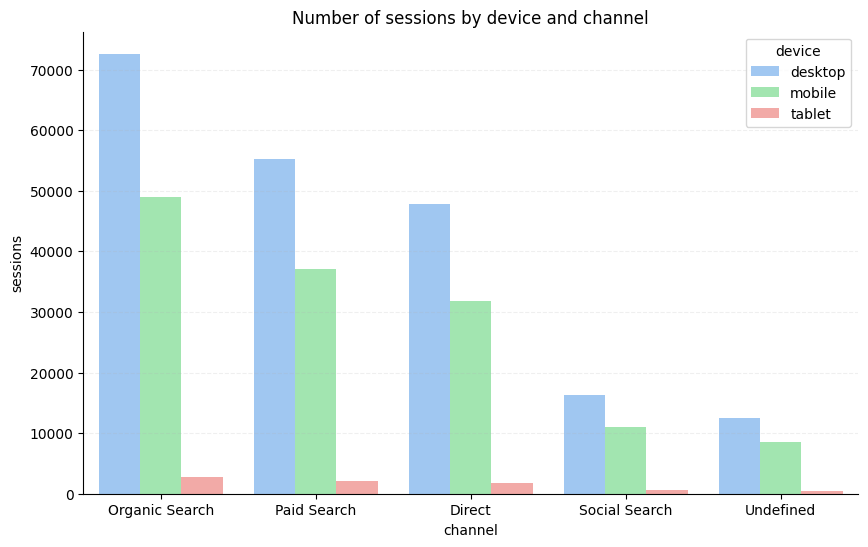

In [ ]:
df_long = df_pivot.melt(id_vars="channel", var_name="device", value_name="sessions")

plt.figure(figsize=(10, 6))

sns.barplot(data=df_long, x="channel", y="sessions", hue="device")
plt.title("Number of sessions by device and channel")
sns.despine()
plt.grid(axis='y', linestyle='--', alpha=0.2)

plt.show()

The main source of traffic is desktop devices, which confidently lead in terms of the number of sessions in all presented channels, while mobile traffic is consistently in second place, and the share of tablets is minimal. Among the channels of engagement, Organic Search demonstrates the greatest activity (where desktop exceeds 70 thousand sessions), followed in descending order by Paid Search, Direct, Social Search and Undefined, and in each of them the ratio between device types remains unchanged.

In [ ]:
top_data = df[(df['country'].isin(country_sales_count['country'])) & (df['product_category'].isin(product_sales['product_category']))]

In [ ]:
df_pivot_sales = top_data.pivot_table(values='item_price', index='product_category', columns='country', aggfunc='sum').sort_values(by='United States', ascending=False)
df_pivot_sales

country,Canada,France,India,United Kingdom,United States
product_category,,,,,
Sofas & armchairs,692427.5,187735.0,788430.0,234812.0,3707144.5
Chairs,417740.8,134029.4,544309.2,188519.4,2619773.8
Beds,354772.0,116414.0,358319.5,133816.0,2213058.0
Bookcases & shelving units,278981.9,73830.0,364507.4,113987.6,1567606.9
Cabinets & cupboards,181802.0,59101.5,191888.0,71684.5,994545.5
Outdoor furniture,185322.8,40486.4,162289.4,57002.4,929245.2
Tables & desks,132678.0,42299.0,186157.5,49374.0,777865.0
Chests of drawers & drawer units,71952.0,21544.5,73111.0,36784.0,382388.0
Bar furniture,51724.0,11199.0,57657.0,22103.0,330805.0


Among the leaders presented, the United States is the absolute favorite in terms of sales volumes in all categories, where its indicators often exceed the results of the other four countries by several times.

The most profitable segments in all the studied markets are upholstered furniture (Sofas & armchairs), chairs (Chairs) and beds (Beds), which generate the main share of revenue. Among other geographies, India takes a confident second place, followed by Canada, while European countries (Great Britain and France) close this five with the lowest activity. The lowest financial result in the top 10 categories is brought by bar and children's furniture, which demonstrate modest revenue figures even in the largest markets.

## Statistical analysis of relationships

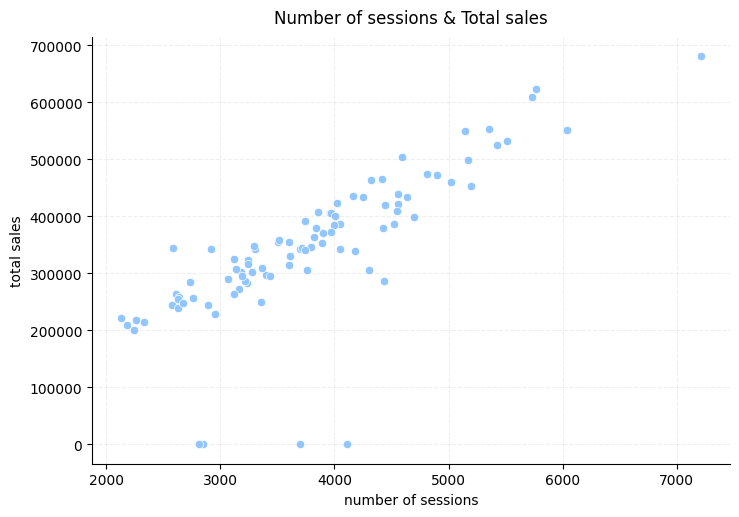

In [ ]:
sessions_revenue = df.groupby('date').agg({'ga_session_id': 'count', 'item_price': 'sum'})

sns.relplot(data=sessions_revenue, x='ga_session_id', y='item_price', aspect=1.5)
plt.title('Number of sessions & Total sales', pad=10)
plt.xlabel('number of sessions')
plt.ylabel('total sales')
plt.grid(linestyle='--', alpha=0.2)
plt.show()

Visually, the number of sessions and total sales indicators have a strong positive relationship. To check the relationship between them, we will calculate the correlation coefficient.

To choose a method for calculating the correlation, we will first check the data for normality of distribution using the D'Agostino-Pearson test:

In [ ]:
stat_sess, p_value_sess = normaltest(sessions_revenue['ga_session_id'])
stat_sales, p_value_sales = normaltest(sessions_revenue['item_price'])

print(f"Sessions: p-value = {p_value_sess:.5f}")
print(f"Sales: p-value = {p_value_sales:.5f}")

Sessions: p-value = 0.00866
Sales: p-value = 0.02109


For both variables p-value < alpha (where $\alpha = 0.05$), the hypothesis of normality is rejected. **The data are NOT normally distributed.**

If at least one of the variables does not obey the normal law, nonparametric methods are used instead of Pearson correlation - most often Spearman's rank correlation coefficient:

In [ ]:
corr_sp, p_value_sp = spearmanr(sessions_revenue['ga_session_id'], sessions_revenue['item_price'])

print(f"Spearman's correlation coefficient: {corr_sp}")
print(f'p_value: {p_value_sp}')

Spearman's correlation coefficient: 0.8653062174563682
p_value: 9.755923586156614e-29


The Spearman correlation coefficient is 0.865, indicating a **very strong positive relationship between the number of sessions and total sales**. This means that as the number of sessions on the site increases, sales volumes show a steady and consistent upward trend.

The resulting p_value is extremely small, which is significantly less than the generally accepted significance threshold of $\alpha = 0.05$. This allows us to confidently reject the null hypothesis of no relationship and to assert that the detected relationship is statistically significant, and not the result of a random coincidence in the data.

## **Conclusions**

The US market is the absolute sales driver, generating almost half of all revenue (about 14 million). India and Canada show good potential, while European markets (UK, France) lag significantly in terms of activity and conversion rates.

The main profit of the business comes from the category of upholstered furniture (sofas, armchairs, beds). At the same time, children's and bar furniture show the lowest profitability even in key markets, freezing part of the capital in inventories.

Most purchases (59%) are made through the desktop version of the Chrome browser, and the main source of customer acquisition is organic search (35.8%).

There is a sharp spike in purchasing activity in the first half of December (pre-New Year shopping) followed by a sharp decline in the second half of the month and in January.

Only 7.99% of sessions come from authorized accounts. However, those users who do register demonstrate high loyalty: the email confirmation rate is over 71%, and the unsubscribe rate from newsletters remains low.

## **Strategic recommendations**

1. **Assortment optimization**

It is worth expanding the assortment in the most profitable categories (Sofas & armchairs, Beds) and implementing recommendation algorithms for related products (for example, offering decorative pillows for sofas) to further increase the average order value (AOV), which currently stands at 953.3.

2. **Geographic expansion**

Increase advertising budgets in the Indian and Canadian markets, which are already showing positive dynamics and are ready for growth.

3. **Technical optimization and traffic diversification**

Since most purchases are completed on desktops, it’s important to conduct a UX audit of your mobile site. Simplifying the checkout process on smartphones can significantly increase the overall conversion rate.

Organic traffic works great, which indicates a high-quality SEO base. However, it is worth diversifying sources: increase paid advertising (PPC) and email marketing, so as not to depend solely on search engine algorithms.

4. **Development of loyalty programs**

Since registered users show high engagement, it is worth incentivizing account creation. For example, offering a 5% discount on the first order for registration or free shipping for authorized users. This will allow you to collect more first-party data for personalized email marketing and increase the LTV (Lifetime Value).

## **Tableau Visualisation**

**[Dashboard link](https://public.tableau.com/views/E-commercesalesanalysis_17796533637900/Dashboard1?:language=en-US&publish=yes&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link)**

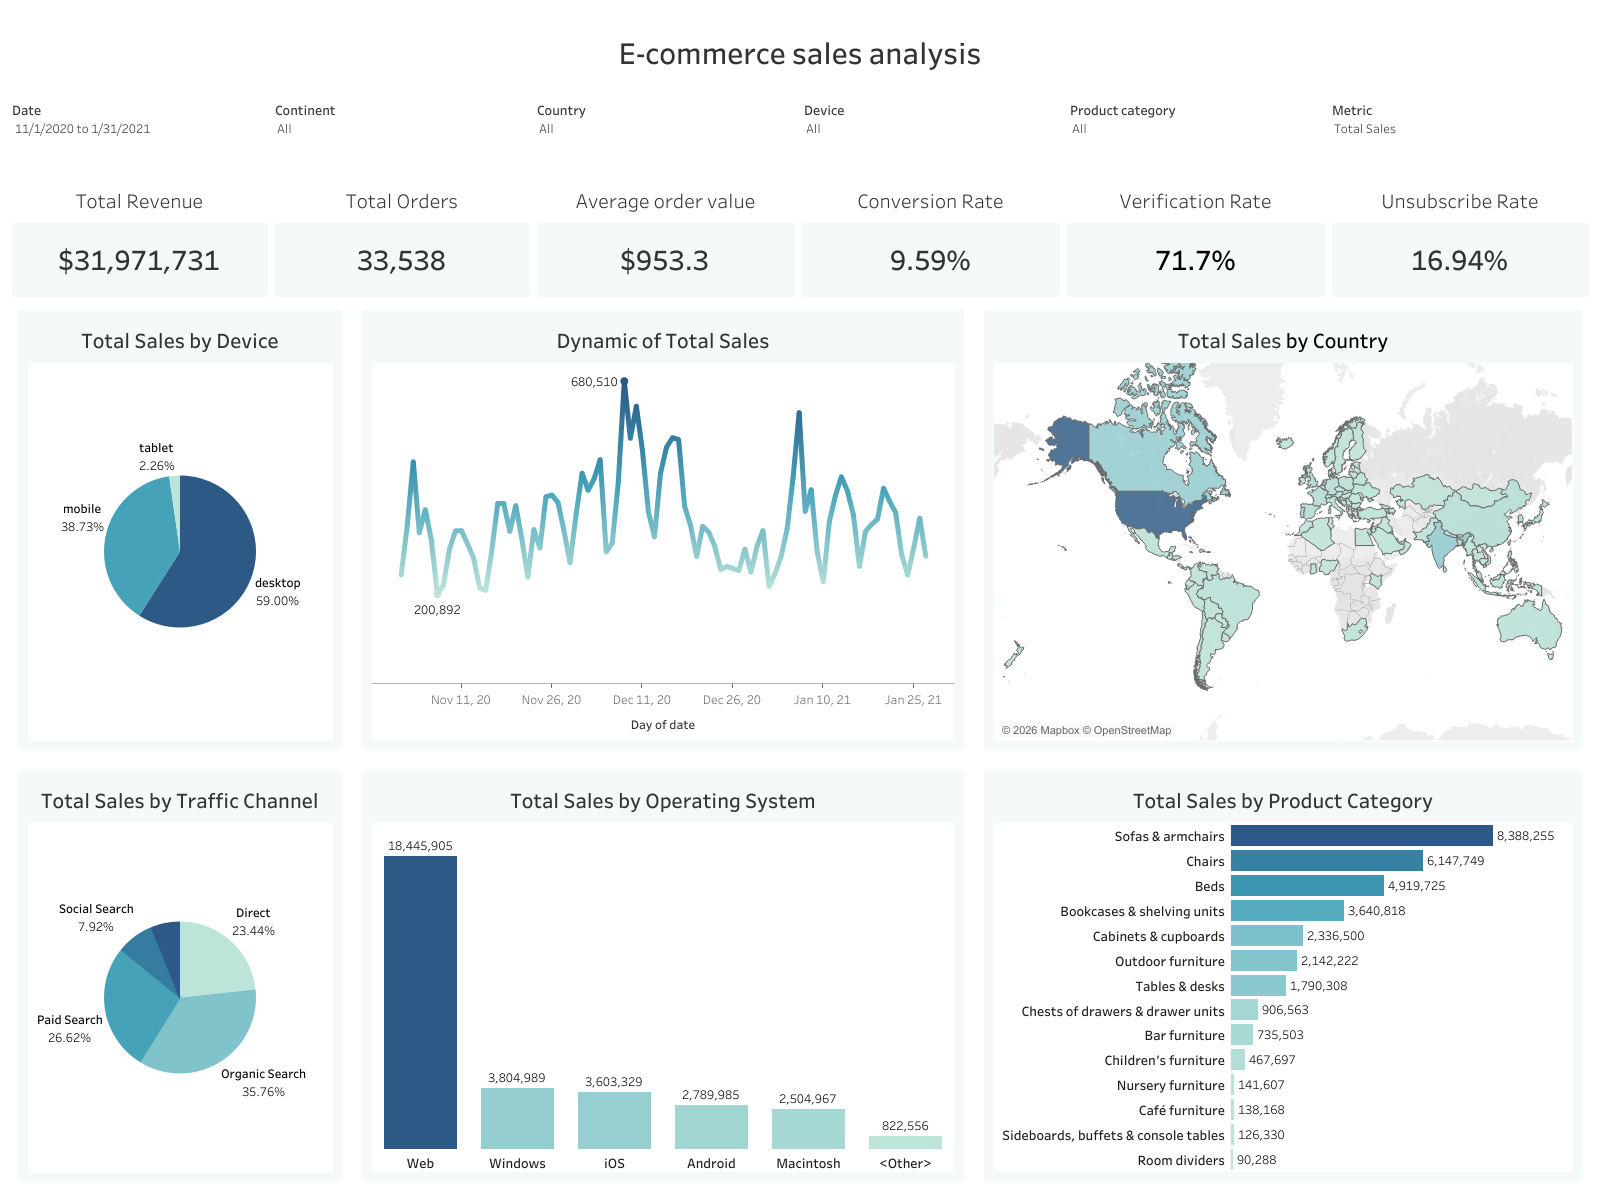